# Assignmnet 2: this line of text is a line of text

# Inspirations

<ul>
<li><a href="https://tigoe.github.io/html-for-conndev/" target="_blank">QR code example from Tom Igoe</a></li>
<li><a href="https://chenqianxun.com/graphein/#:~:text=1.1%20THE%20COPYBOOK%20%E7%BF%92%E5%AD%97%E5%B8%96">Qianxun Chen, Graphein</a></li>
<li><a href="https://juerglehni.com/works/empty-words">Jürg Lehni & Alex Rich, Empty words</a></li>
<li><a href="https://chenqianxun.com/graphein/#:~:text=1.1%20THE%20COPYBOOK%20%E7%BF%92%E5%AD%97%E5%B8%96">Qianxun Chen, Graphein</a></li>
</ul>

In [3]:
!pip install qrcode

In [4]:
import qrcode
import random
from IPython.display import display, HTML

In [5]:
def mkdiv(content, **kwargs):
    style_str = "; ".join([f"{k.replace('_', '-')}: {v}" for k, v in kwargs.items()])
    return f'<div style="{style_str}">{content}</div>'

In [6]:
def show_html(src):
    return display(HTML(src), metadata=dict(isolated=True))

## Chapter 1: About Blocks

#### QR code

1. Size: version number in qrcode.QRCode(version=n) defines an nxn grid
3. min Version = 1 (21x21).
4. max Version = 40 (177x177 modules).
5. each version increases the size by 4x4 (Version 2 = 25x25, Version 3 = 29x29).
6. higher versions -> store more data; larger scale.
7. Error Correction Levels: Higher versions -> better error correction but reduce data capacity: L (Low, ~7% recovery); M (Medium, ~15% recovery); Q (Quartile, ~25% recovery); H (High, ~30% recovery)


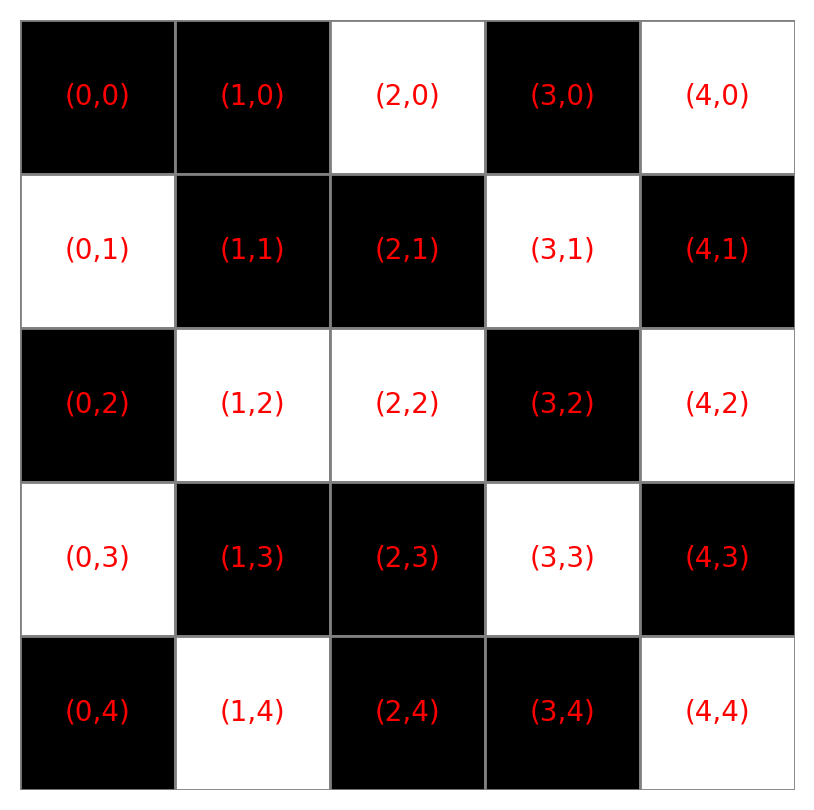

In [7]:
poem_text = "thislineoftextisalineoftext"
target = "https://itp.nyu.edu/itp/"

In [8]:
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_L,
    box_size=10,
    border=4,
)
qr.add_data(target)
qr.make(fit=True)

In [9]:
#get matrix
matrix = qr.get_matrix()
qr_size = len(matrix)

In [10]:
#set size for each blcok
block_size = 20
container_size = qr_size * block_size

#### Create HTML divs

In [11]:
divs = []
char_index = 0

In [12]:
poem_chars = list(poem_text)
while len(poem_chars) < sum(sum(row) for row in matrix):
    poem_chars.extend(list(poem_text))

In [35]:
for y in range(qr_size):
    for x in range(qr_size):
        left = x * block_size
        top = y * block_size
        
        if matrix[y][x]:
            # blk blocks
            char = poem_chars[char_index % len(poem_chars)]
            char_index += 1
            
            div = mkdiv(
                char,
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                font_size="14px",
                font_weight="bold",
                display="flex",
                justify_content="center",
                align_items="center",
                background_color="black",
                color="white"
            )
        else:
            # white blocks
            div = mkdiv(
                " ",
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                background_color="white"
            )
        
        divs.append(div)


#### HTML template

In [36]:
html_tmpl = """<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="utf-8">
    <title>Scan</title>
    <style>
    html {{ min-height: 32em; overflow: hidden; }}
    </style>
</head>
<body>
{content}
</body>
</html>"""

In [37]:
html_src = html_tmpl.format(content="".join(divs))

In [38]:
show_html(html_src)

## Chapter 2: Text as Blocks

In [39]:
qr = qrcode.QRCode(
    version=1,
    error_correction=qrcode.constants.ERROR_CORRECT_H, 
    box_size=10,
    border=4,
)
qr.add_data(target)
qr.make(fit=True)

In [40]:
matrix = qr.get_matrix()
qr_size = len(matrix)

In [41]:
poem_chars = list(poem_text.replace(" ", "#"))
while len(poem_chars) < sum(sum(row) for row in matrix):
    poem_chars.extend(list(poem_text.replace(" ", "#")))

In [42]:
# set size for each block
block_size = 20
container_size = qr_size * block_size

In [43]:
# html divs
divs = []
char_index = 0

In [44]:
for y in range(qr_size):
    for x in range(qr_size):
        left = x * block_size
        top = y * block_size
        
        if matrix[y][x]:
            # black blocks
            char = poem_chars[char_index % len(poem_chars)]
            char_index += 1
            
            div = mkdiv(
                char,
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                font_size="16px",
                font_weight="bold",
                display="flex",
                justify_content="center",
                align_items="center",
                color="black",
                background_color="white"
                
            )
        else:
            # white blocks
            div = mkdiv(
                "·",
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                font_size="8px",
                font_weight="100",
                display="flex",
                justify_content="center",
                align_items="center",
                color="#EEEEEE"
            )
        
        divs.append(div)

#### html

In [45]:
html_src = html_tmpl.format(content="".join(divs))

In [46]:
show_html(html_src)

## Chapter 3: More Texts per Block

In [47]:
for y in range(qr_size):
    for x in range(qr_size):
        left = x * block_size
        top = y * block_size
        
        if matrix[y][x]:
            # blk blocks
            char = poem_chars[char_index % len(poem_chars)]
            char_index += 1
            
            div = mkdiv(
                char,
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                font_size="16px",
                font_weight="bold",
                display="flex",
                justify_content="center",
                align_items="center",
                color="black",
                background_color="white"
                
            )
        else:
            # white blocks
            div = mkdiv(
                "·",
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                font_size="8px",
                font_weight="100",
                display="flex",
                justify_content="center",
                align_items="center",
                color="#EEEEEE"
            )
        
        divs.append(div)

In [48]:
qr = qrcode.QRCode(
    version=2,
    error_correction=qrcode.constants.ERROR_CORRECT_H,  # Higher error correction
    box_size=10,
    border=4,
)
qr.add_data(target)
qr.make(fit=True)

In [49]:
matrix = qr.get_matrix()
qr_size = len(matrix)

#### clean poem text and remove extra spaces

In [50]:
clean_poem = poem_text.replace("\n", " ").strip()
while "  " in clean_poem:
    clean_poem = clean_poem.replace("  ", " ")

In [51]:
poem_chars = list(clean_poem)
# use 4 chars per blcok
while len(poem_chars) < sum(sum(row) for row in matrix) * 4:
    poem_chars.extend(list(clean_poem))

In [52]:
block_size = 18
container_size = qr_size * block_size
divs = []
char_index = 0

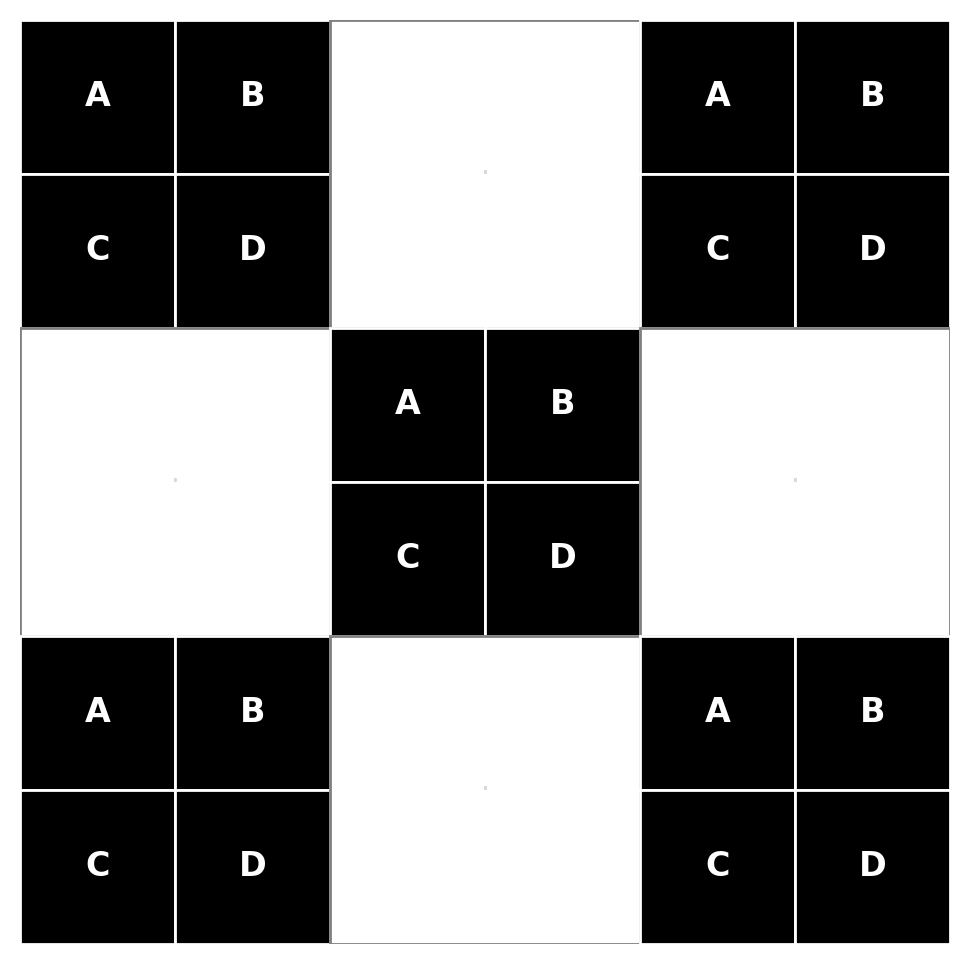

In [53]:
for y in range(qr_size):
    for x in range(qr_size):
        left = x * block_size
        top = y * block_size
        
        if matrix[y][x]:
            # blk blocks
            # use 4 characters in a 2x2 grid for each block
            
            # top left
            topleft = poem_chars[char_index % len(poem_chars)]
            char_index += 1
            divs.append(mkdiv(
                topleft,
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size/2}px",
                height=f"{block_size/2}px",
                font_size="10px",
                font_weight="900",
                display="flex",
                justify_content="center",
                align_items="center",
                color="black"
            ))
            
            # top right
            topright = poem_chars[char_index % len(poem_chars)]
            char_index += 1
            divs.append(mkdiv(
                topright,
                position="absolute",
                top=f"{top}px",
                left=f"{left + block_size/2}px",
                width=f"{block_size/2}px",
                height=f"{block_size/2}px",
                font_size="10px",
                font_weight="900",
                display="flex",
                justify_content="center",
                align_items="center",
                color="black"
            ))
            
            # bottom left character
            bottomleft = poem_chars[char_index % len(poem_chars)]
            char_index += 1
            divs.append(mkdiv(
                bottomleft,
                position="absolute",
                top=f"{top + block_size/2}px",
                left=f"{left}px",
                width=f"{block_size/2}px",
                height=f"{block_size/2}px",
                font_size="10px",
                font_weight="900",
                display="flex",
                justify_content="center",
                align_items="center",
                color="black"
            ))
            
            # bottom right
            bottomright = poem_chars[char_index % len(poem_chars)]
            char_index += 1
            divs.append(mkdiv(
                bottomright,
                position="absolute",
                top=f"{top + block_size/2}px",
                left=f"{left + block_size/2}px",
                width=f"{block_size/2}px",
                height=f"{block_size/2}px",
                font_size="10px",
                font_weight="900",
                display="flex",
                justify_content="center",
                align_items="center",
                color="black"
            ))
        else:
            # white block
            divs.append(mkdiv(
                "·",
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                font_size="8px",
                font_weight="100",
                display="flex",
                justify_content="center",
                align_items="center",
                color="#F8F8F8",
                opacity="0"
            ))

In [54]:
html_src = html_tmpl.format(content="".join(divs))

In [55]:
show_html(html_src)

## Chapter 4:  Definition of a Block

#### 16 chars per block

In [84]:
while len(poem_chars) < sum(sum(row) for row in matrix) * 16:
    poem_chars.extend(list(poem_text.replace(" ", "#")))

In [85]:
block_size = 20
container_size = qr_size * block_size
divs = []
char_index = 0

In [86]:
for y in range(qr_size):
    for x in range(qr_size):
        left = x * block_size
        top = y * block_size
        
        if matrix[y][x]:
            # black block: a 4x4 grid
            for i in range(4):
                for j in range(4):
                    char = poem_chars[char_index % len(poem_chars)]
                    char_index += 1
                    
                    divs.append(mkdiv(
                        char,
                        position="absolute",
                        top=f"{top + (i*block_size/4)}px",
                        left=f"{left + (j*block_size/4)}px",
                        width=f"{block_size/4}px",
                        height=f"{block_size/4}px",
                        font_size="8px",
                        font_weight="900",
                        display="flex",
                        justify_content="center",
                        align_items="center",
                        color="black",
                        background_color="#FFFFFF", 
                        text_decoration="none",
                        text_shadow="none",
                        border_radius="0"
                    ))
        else:
            # white block
            divs.append(mkdiv(
                " ",
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                background_color="#FFFFFF", 
                opacity="0" 
            ))


In [79]:
for y in range(qr_size):
    for x in range(qr_size):
        left = x * block_size
        top = y * block_size

        
        if matrix[y][x]:

            # white block
            divs.append(mkdiv(
                " ",
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                background_color="#FFFFFF", 
                opacity="0" 
            ))
            
        else:
            # black block: a 4x4 grid
            for i in range(4):
                for j in range(4):
                    char = poem_chars[char_index % len(poem_chars)]
                    char_index += 1
                    
                    divs.append(mkdiv(
                        char,
                        position="absolute",
                        top=f"{top + (i*block_size/4)}px",
                        left=f"{left + (j*block_size/4)}px",
                        width=f"{block_size/4}px",
                        height=f"{block_size/4}px",
                        font_size="8px",
                        font_weight="900",
                        display="flex",
                        justify_content="center",
                        align_items="center",
                        color="black",
                        background_color="#FFFFFF", 
                        text_decoration="none",
                        text_shadow="none",
                        border_radius="0"
                    ))


In [87]:
html_src = html_tmpl.format(content="".join(divs))

In [88]:
show_html(html_src)

In [61]:
block_size = 20
container_size = qr_size * block_size
divs = []
char_index = 0

In [62]:
for y in range(qr_size):
    for x in range(qr_size):
        left = x * block_size
        top = y * block_size
        
        if matrix[y][x]:
            # black block: a 8x8 grid
            for i in range(8):
                for j in range(8):
                    char = poem_chars[char_index % len(poem_chars)]
                    char_index += 1
                    
                    divs.append(mkdiv(
                        char,
                        position="absolute",
                        top=f"{top + (i*block_size/8)}px",
                        left=f"{left + (j*block_size/8)}px",
                        width=f"{block_size/8}px",
                        height=f"{block_size/8}px",
                        font_size="2px",
                        font_weight="900",
                        display="flex",
                        justify_content="center",
                        align_items="center",
                        color="black",
                        background_color="#FFFFFF", 
                        text_decoration="none",
                        text_shadow="none", 
                        border_radius="0"
                    ))
        else:
            # white block
            divs.append(mkdiv(
                " ",
                position="absolute",
                top=f"{top}px",
                left=f"{left}px",
                width=f"{block_size}px",
                height=f"{block_size}px",
                background_color="#FFFFFF",
                opacity="0"
            ))


In [63]:
html_src = html_tmpl.format(content="".join(divs))